In [8]:
## notebook to analyze a frequency sweep electrically driving the plate to measure the
## transfer function versus frequency 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib, os, pyvisa
sys.path.append("labjack")
sys.path.append("..")
from functiongenerator import AFG2225
import labjack_utils as lu
from ReadPressure import read_pressure
import datetime, time
# import msvcrt # for windows, key press detection--only if .py file is run

In [69]:
## data acquisition parameters:
sampling_rate = 1000 #Hz
num_samples = 2**14 #1 s per file
num_traces_per_file = 10 ## number of waveforms to save per file
num_files = 1 # number of files

set_synth = True
synth_channel = 1 ## must be 1 or 2
noise_playback_freq = 0.086 #Hz
synth_amplitude = 20 #Vpp

save_data = True
output_path = "C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250401/"

plot_data = True

save_pressure = True
pressure_port = "COM6"

if(not os.path.isdir(output_path)):
    os.makedirs(output_path)

In [71]:
#set noise on function generator if desired
if(set_synth):

    afg = AFG2225("ASRL3::INSTR")
    afg.set_output_onoff(synth_channel, "OFF")
    afg.set_amplitude(synth_channel, synth_amplitude)
    afg.set_frequency(synth_channel, noise_playback_freq)
    afg.set_output_onoff(synth_channel, "ON")

In [103]:
importlib.reload(lu)

lj = lu.LabJack()

channels_to_read = [0,1,2,3]
ch_names = ['X', 'Y', 'Sum', 'Drive']
num_channels = len(channels_to_read)

## open labjack ad configure
lj.open()
lj.config(sample_rate=sampling_rate, num_samps_to_read=num_samples, channel_list=channels_to_read,)

Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.


got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Start pressure: 1.18e-02 mbar, end pressure: 1.18e-02 mbar


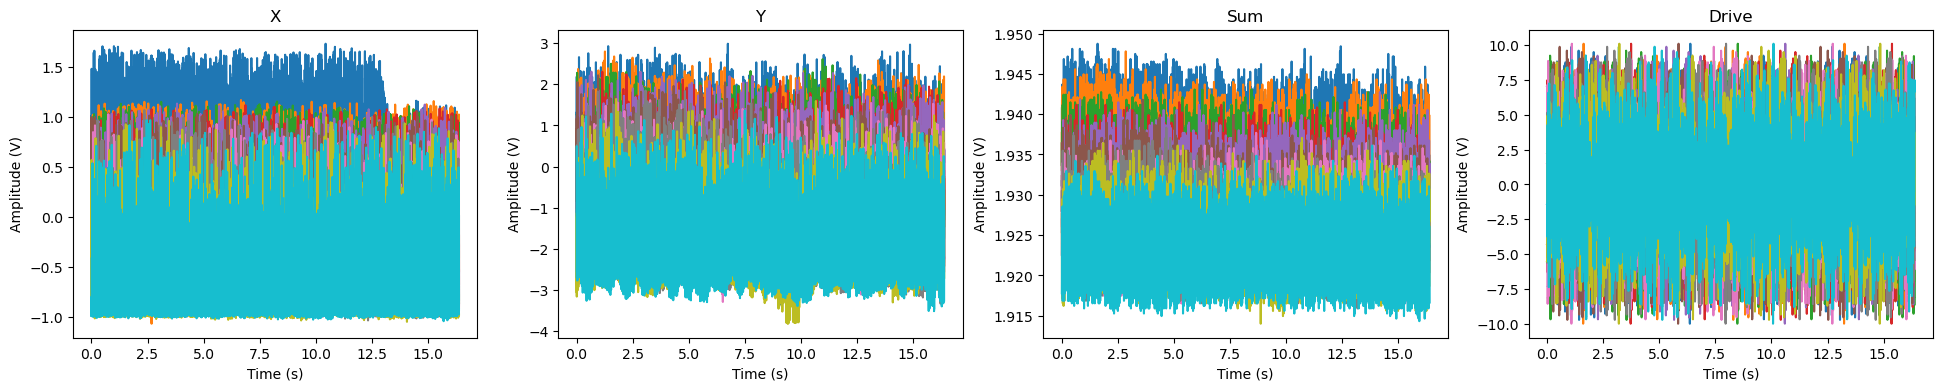

In [104]:
if(save_pressure):
    start_pressure = read_pressure(pressure_port)

data, totSkip = lj.read_analog_in(num_scans=num_traces_per_file)

if(save_pressure):
    end_pressure = read_pressure(pressure_port)

if(totSkip > 0):
    print("Warning: Skipped {} samples".format(totSkip))

if(save_data):
    if(save_pressure):
        pressure_data = [start_pressure, end_pressure]
        print("Start pressure: %.2e mbar, end pressure: %.2e mbar"%(start_pressure, end_pressure))
    else:
        pressure_data = None
    
    if(save_pressure):
        filename = output_path + "transfer_func_data_noise_%.3fHz_%.3fV_%.2embar.npz"%(noise_playback_freq, synth_amplitude, start_pressure)
    else:
        filename = output_path + "transfer_func_data_noise_%.3fHz_%.3fV.npz"%(noise_playback_freq, synth_amplitude)
    np.savez(filename, data = data, Fs=sampling_rate, noise_playback_freq=noise_playback_freq, 
             synth_amplitude=synth_amplitude, pressure_data=pressure_data)

if(plot_data):
    ## plot data
    time_vec = np.arange(num_samples)/sampling_rate

    plt.figure(figsize=(6*num_channels,4))
    for i in range(num_traces_per_file):
        for ch in range(num_channels):
            plt.subplot(1,num_channels,ch+1)
            plt.plot(time_vec, data[i][:,ch])
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude (V)")
            plt.title(ch_names[ch])
    plt.show()

lj.close()

In [47]:
print(read_pressure(pressure_port))

4.68e-07


Starting acquisition loop. Press 'q' to quit.

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1634_noise_0.086Hz_20.000V_9.79e-07mbar.npz
Start pressure: 9.79e-07 mbar, End pressure: 7.46e-07 mbar


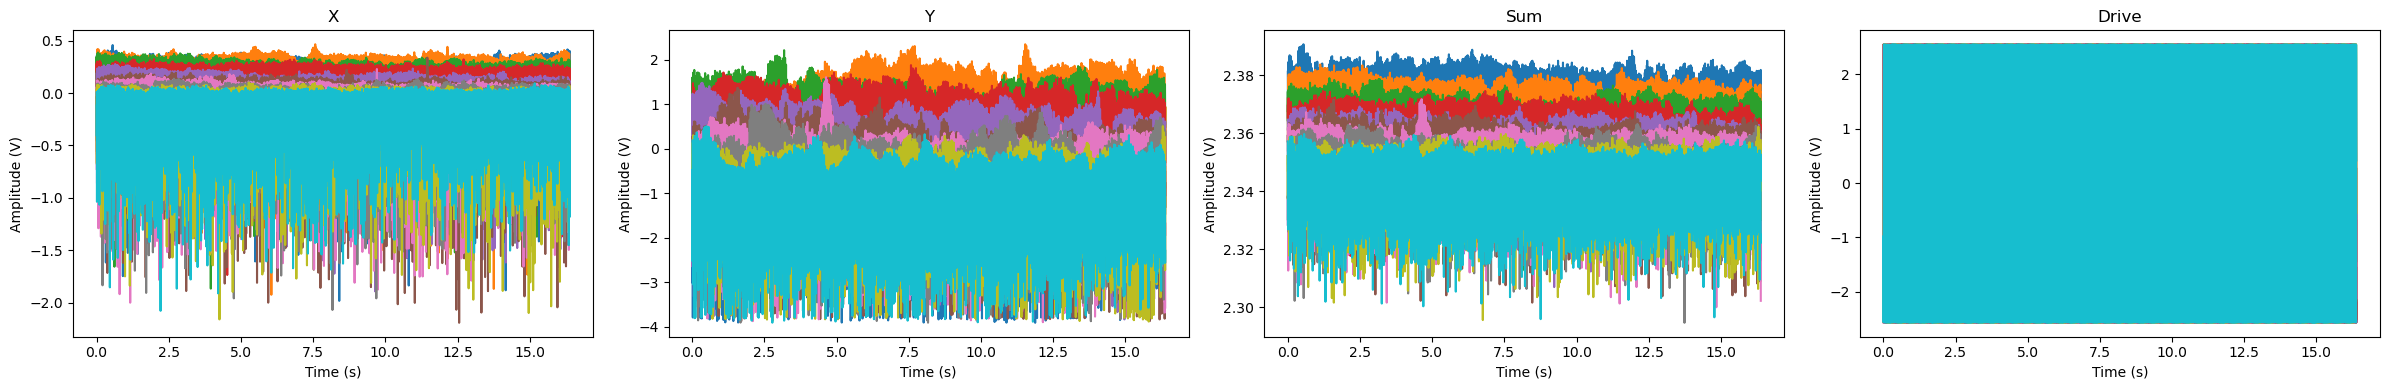

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1637_noise_0.086Hz_20.000V_7.46e-07mbar.npz
Start pressure: 7.46e-07 mbar, End pressure: 6.80e-07 mbar


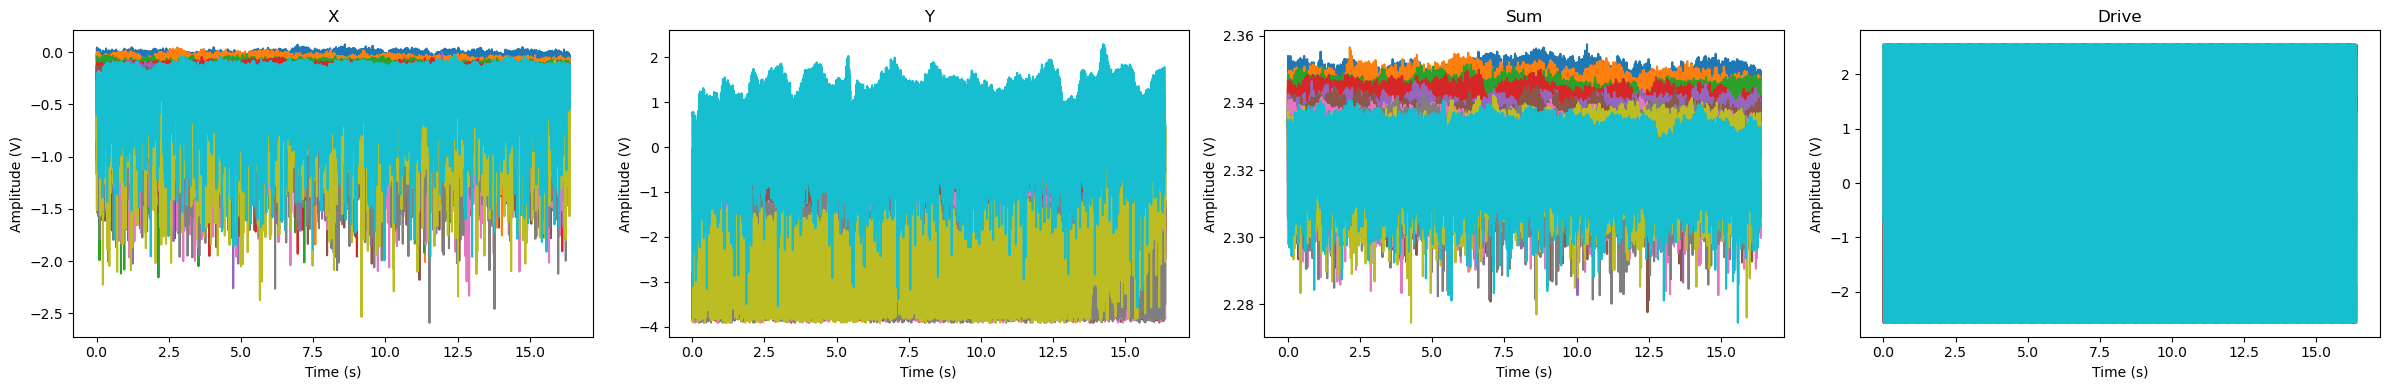

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1639_noise_0.086Hz_20.000V_6.78e-07mbar.npz
Start pressure: 6.78e-07 mbar, End pressure: 6.46e-07 mbar


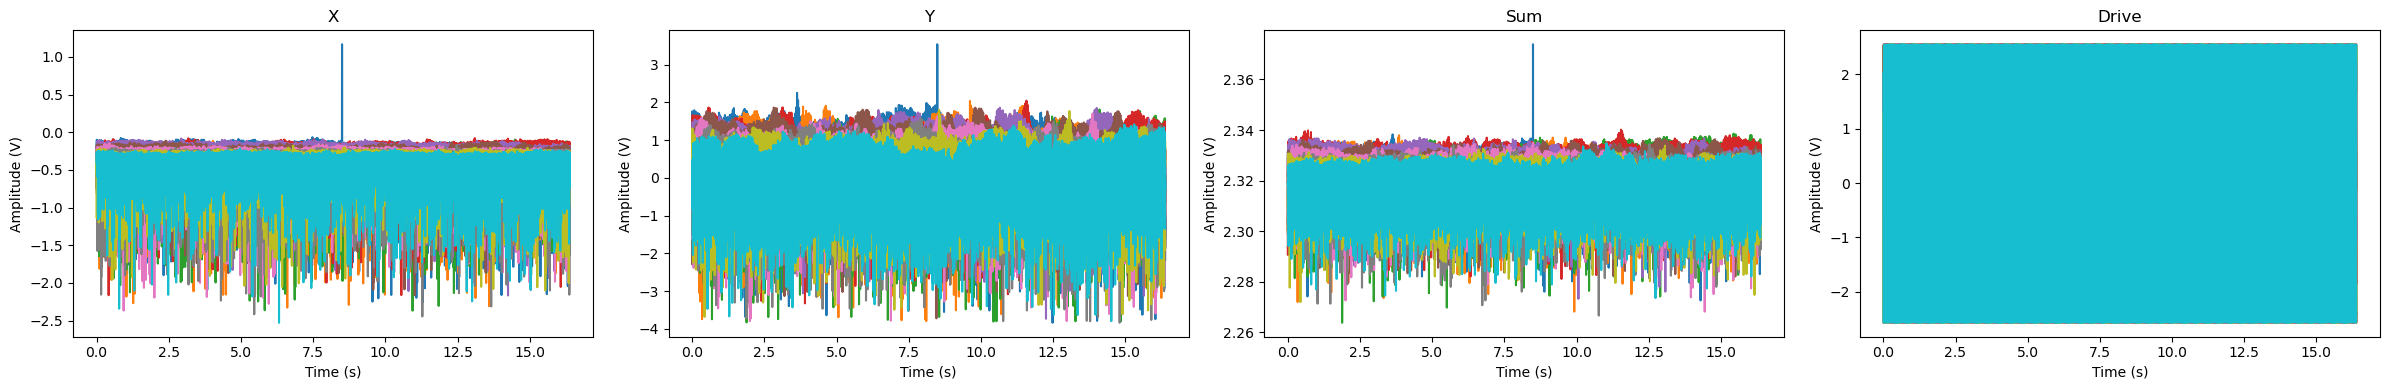

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1642_noise_0.086Hz_20.000V_6.46e-07mbar.npz
Start pressure: 6.46e-07 mbar, End pressure: 6.34e-07 mbar


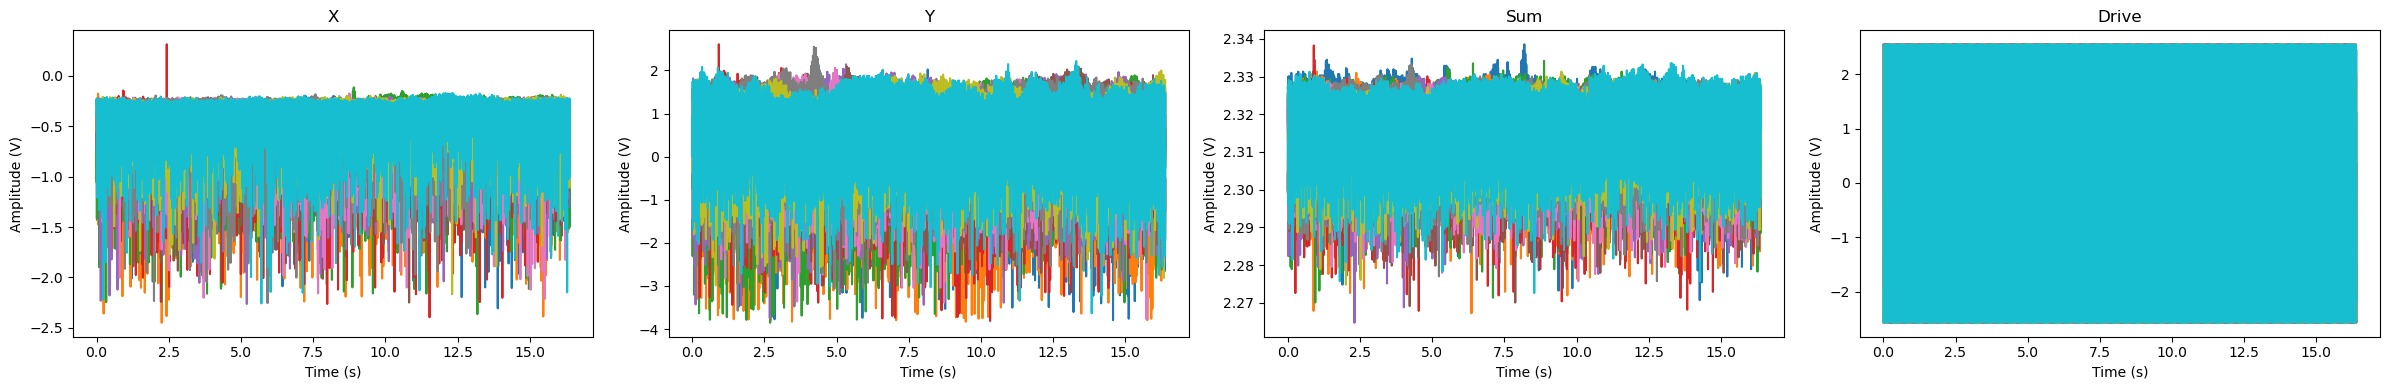

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1645_noise_0.086Hz_20.000V_6.34e-07mbar.npz
Start pressure: 6.34e-07 mbar, End pressure: 6.15e-07 mbar


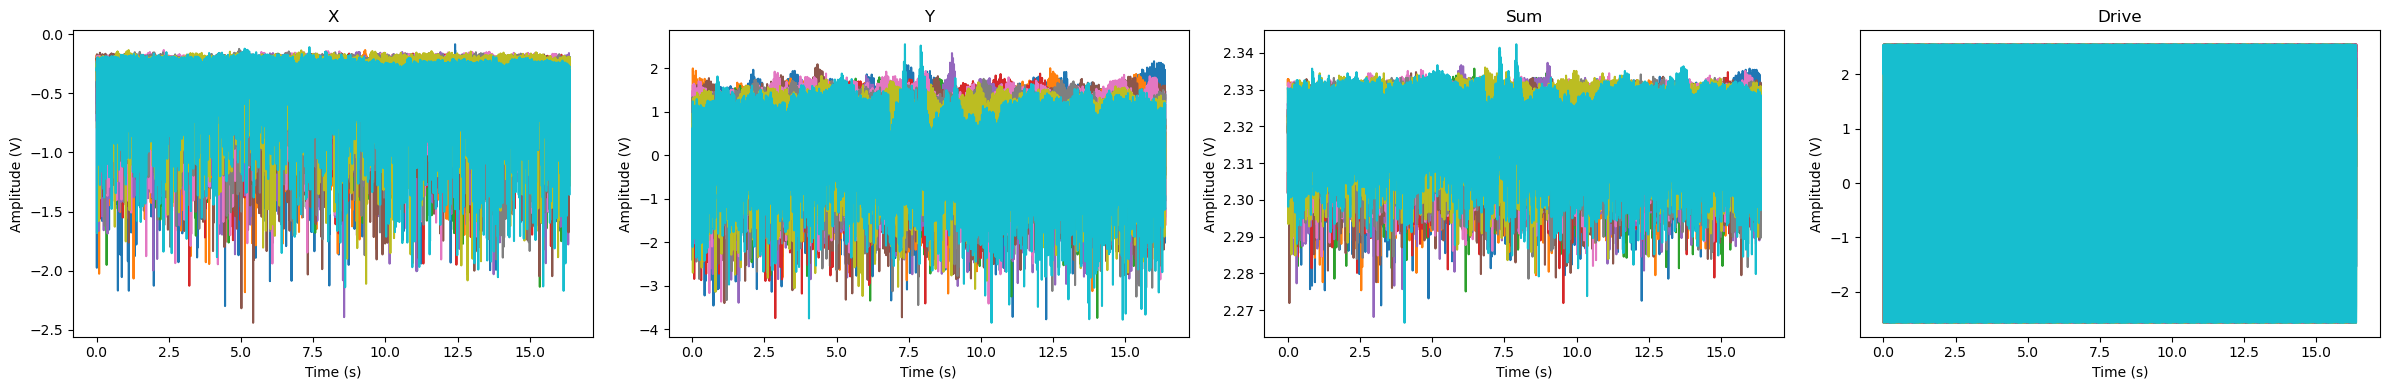

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1647_noise_0.086Hz_20.000V_6.15e-07mbar.npz
Start pressure: 6.15e-07 mbar, End pressure: 6.02e-07 mbar


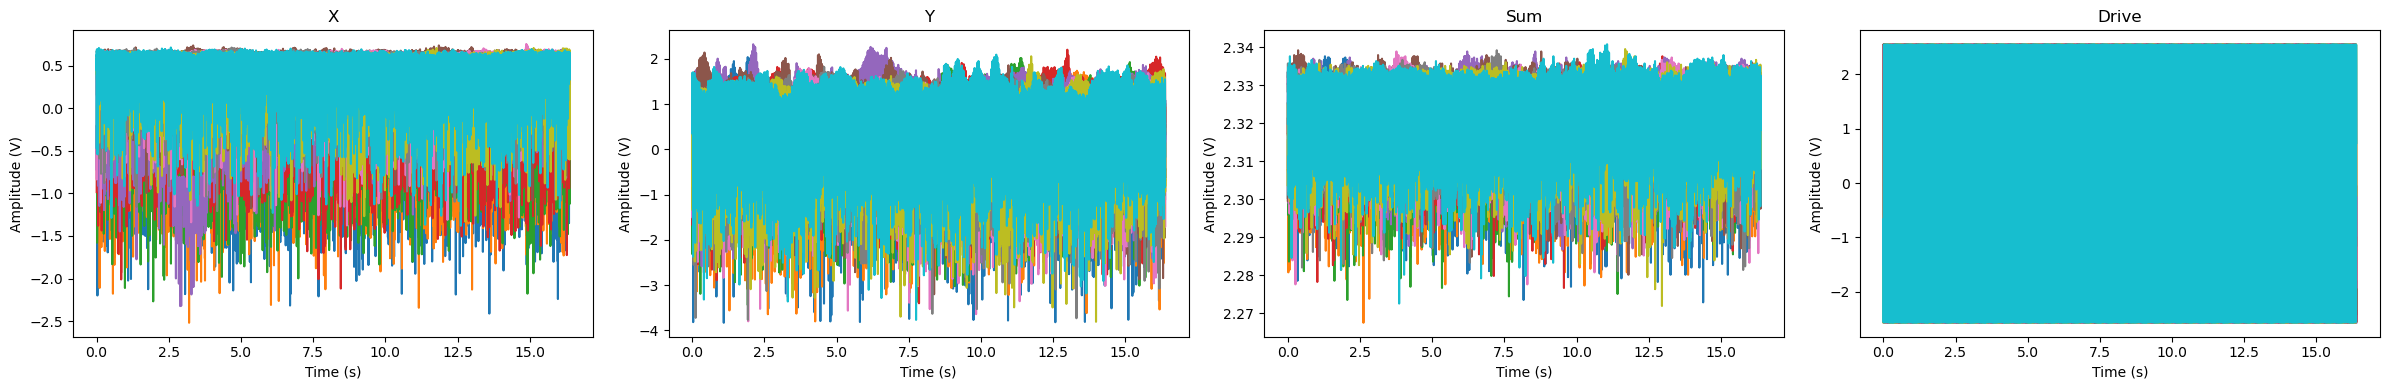

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1650_noise_0.086Hz_20.000V_6.04e-07mbar.npz
Start pressure: 6.04e-07 mbar, End pressure: 5.91e-07 mbar


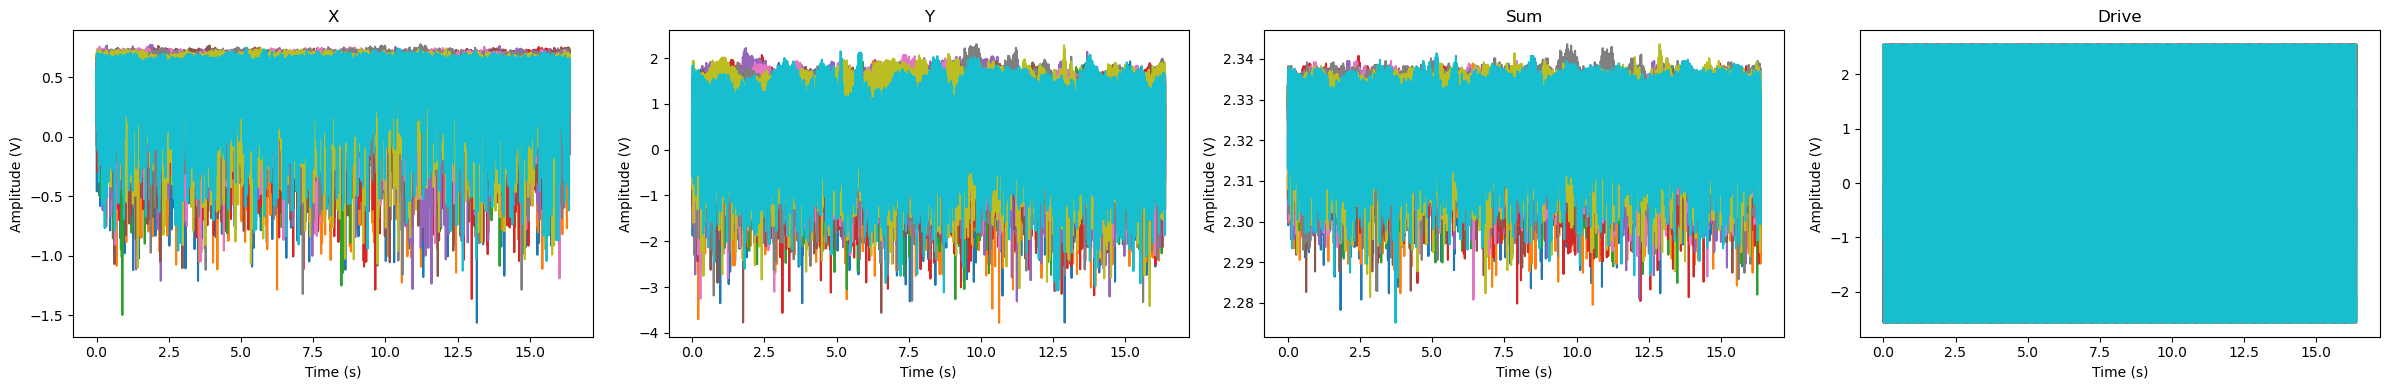

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1653_noise_0.086Hz_20.000V_5.93e-07mbar.npz
Start pressure: 5.93e-07 mbar, End pressure: 5.91e-07 mbar


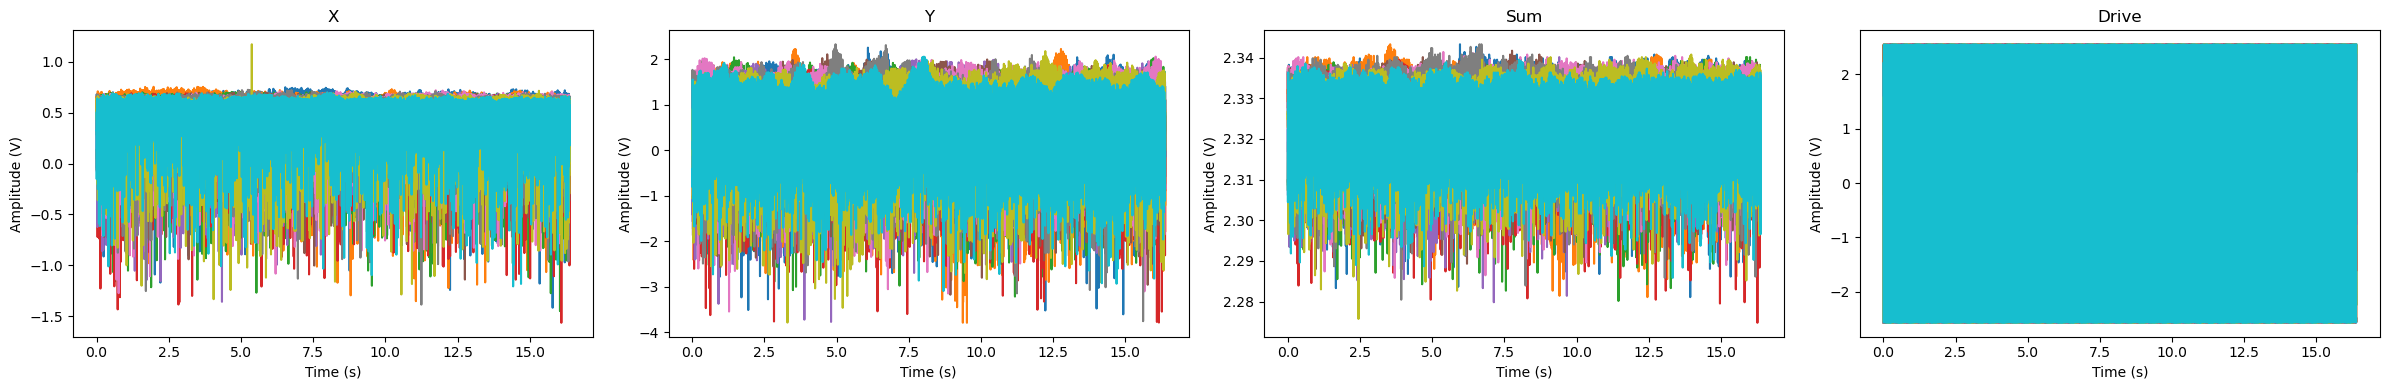

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1656_noise_0.086Hz_20.000V_5.91e-07mbar.npz
Start pressure: 5.91e-07 mbar, End pressure: 5.81e-07 mbar


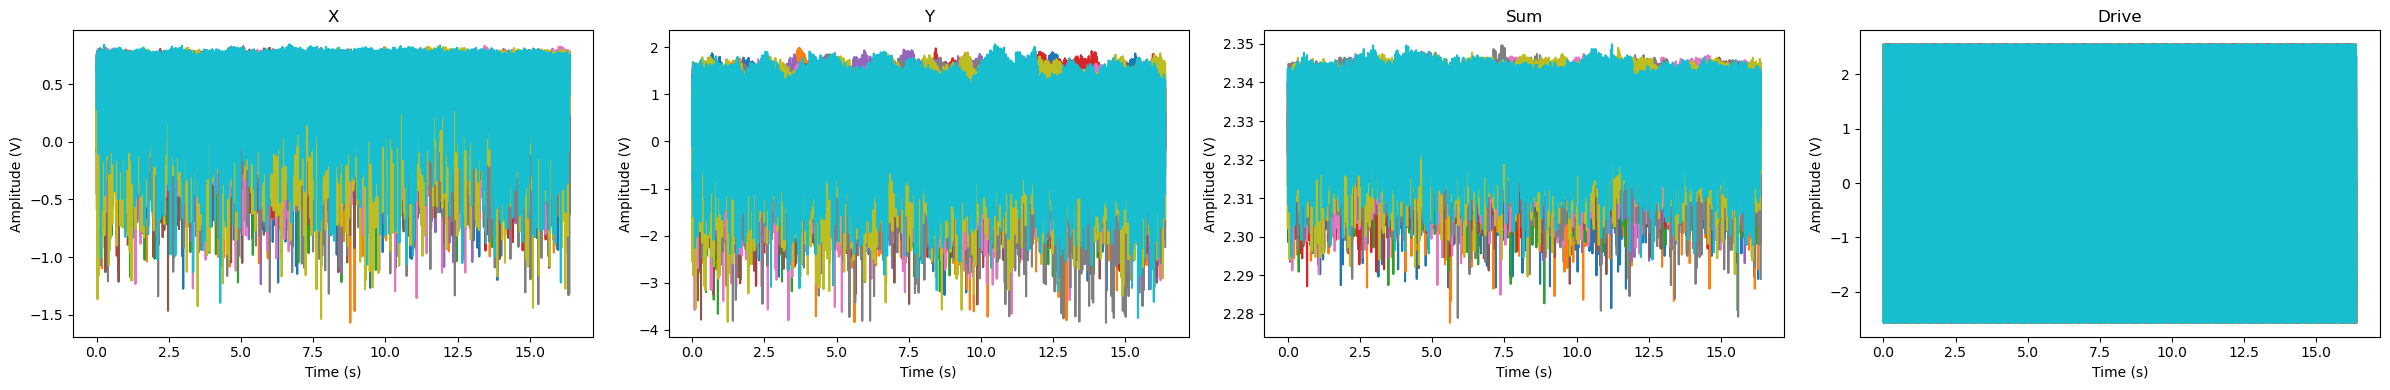

got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
got data:  65536
Saved file: C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/20250328/transfer_func_data_UV_1658_noise_0.086Hz_20.000V_5.83e-07mbar.npz
Start pressure: 5.83e-07 mbar, End pressure: 5.81e-07 mbar


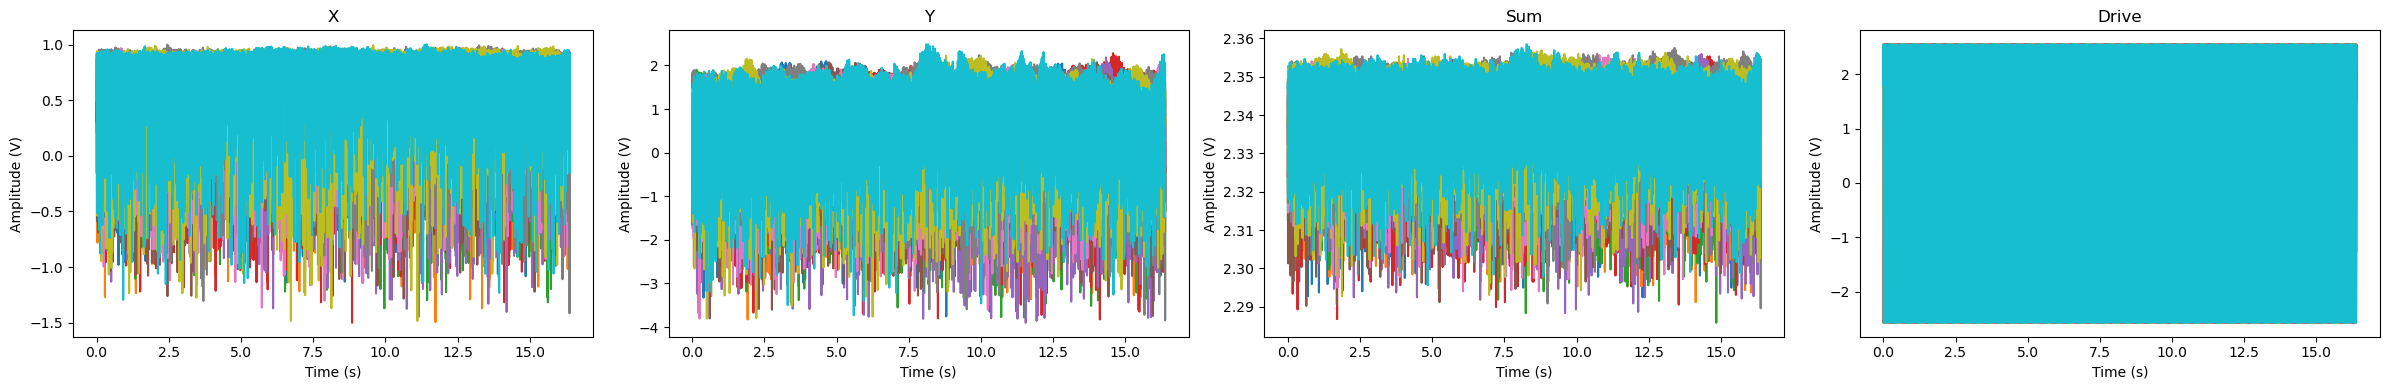

got data:  65536
got data:  65536
got data:  65536
got data:  65536
Interrupted with Ctrl+C.
DAQ connection closed.


In [67]:
# For continuous data acquisition, use the following code:

def get_timestamp():
    return datetime.datetime.now().strftime("%H%M")

print("Starting acquisition loop. Press 'q' to quit.\n")

try:
    while True:
        # --- Check for quit key ---
        if msvcrt.kbhit():
            key = msvcrt.getch().decode('utf-8')
            if key.lower() == 'q':
                print("Quit key detected. Exiting loop.")
                break

        # --- Read starting pressure ---
        if save_pressure:
            start_pressure = read_pressure(pressure_port)

        # --- Acquire data ---
        data, totSkip = lj.read_analog_in(num_scans=num_traces_per_file)

        # --- Read ending pressure ---
        if save_pressure:
            end_pressure = read_pressure(pressure_port)

        if totSkip > 0:
            print("Warning: Skipped {} samples".format(totSkip))

        # --- Save data ---
        if save_data:
            timestamp = get_timestamp()
            pressure_data = [start_pressure, end_pressure] if save_pressure else None

            if save_pressure:
                filename = (
                    output_path +
                    f"transfer_func_data_UV_{timestamp}_noise_{noise_playback_freq:.3f}Hz_"
                    f"{synth_amplitude:.3f}V_{start_pressure:.2e}mbar.npz"
                )
            else:
                filename = (
                    output_path +
                    f"transfer_func_data_{timestamp}_noise_{noise_playback_freq:.3f}Hz_"
                    f"{synth_amplitude:.3f}V.npz"
                )

            np.savez(
                filename,
                data=data,
                Fs=sampling_rate,
                noise_playback_freq=noise_playback_freq,
                synth_amplitude=synth_amplitude,
                pressure_data=pressure_data
            )
            print(f"Saved file: {filename}")
            if save_pressure:
                print(f"Start pressure: {start_pressure:.2e} mbar, End pressure: {end_pressure:.2e} mbar")

        # plotting for visual check
        if plot_data:
            time_vec = np.arange(num_samples) / sampling_rate
            plt.figure(figsize=(6 * num_channels, 4))
            for i in range(num_traces_per_file):
                for ch in range(num_channels):
                    plt.subplot(1, num_channels, ch + 1)
                    plt.plot(time_vec, data[i][:, ch])
                    plt.xlabel("Time (s)")
                    plt.ylabel("Amplitude (V)")
                    plt.title(ch_names[ch])
            plt.tight_layout()
            plt.show()

        # delay to avoid immediate re-triggering, maybe erase
        time.sleep(1)

except KeyboardInterrupt:
    print("Interrupted with Ctrl+C.")

finally:
    lj.close()
    print("DAQ connection closed.")

In [ ]:
# For continuous data acquisition, use the following code:

def get_timestamp():
    return datetime.datetime.now().strftime("%H%M")

print("Starting acquisition loop. Press 'q' to quit.\n")

try:
    while True:
        # --- Check for quit key ---
        if msvcrt.kbhit():
            key = msvcrt.getch().decode('utf-8')
            if key.lower() == 'q':
                print("Quit key detected. Exiting loop.")
                break

        # --- Read starting pressure ---
        if save_pressure:
            start_pressure = read_pressure(pressure_port)

        # --- Acquire data ---
        data, totSkip = lj.read_analog_in(num_scans=num_traces_per_file)

        # --- Read ending pressure ---
        if save_pressure:
            end_pressure = read_pressure(pressure_port)

        if totSkip > 0:
            print("Warning: Skipped {} samples".format(totSkip))

        # --- Save data ---
        if save_data:
            timestamp = get_timestamp()
            pressure_data = [start_pressure, end_pressure] if save_pressure else None

            if save_pressure:
                filename = (
                    output_path +
                    f"transfer_func_data_{timestamp}_noise_{noise_playback_freq:.3f}Hz_"
                    f"{synth_amplitude:.3f}V_{start_pressure:.2e}mbar.npz"
                )
            else:
                filename = (
                    output_path +
                    f"transfer_func_data_{timestamp}_noise_{noise_playback_freq:.3f}Hz_"
                    f"{synth_amplitude:.3f}V.npz"
                )

            np.savez(
                filename,
                data=data,
                Fs=sampling_rate,
                noise_playback_freq=noise_playback_freq,
                synth_amplitude=synth_amplitude,
                pressure_data=pressure_data
            )
            print(f"Saved file: {filename}")
            if save_pressure:
                print(f"Start pressure: {start_pressure:.2e} mbar, End pressure: {end_pressure:.2e} mbar")

        # plotting for visual check
        if plot_data:
            time_vec = np.arange(num_samples) / sampling_rate
            plt.figure(figsize=(6 * num_channels, 4))
            for i in range(num_traces_per_file):
                for ch in range(num_channels):
                    plt.subplot(1, num_channels, ch + 1)
                    plt.plot(time_vec, data[i][:, ch])
                    plt.xlabel("Time (s)")
                    plt.ylabel("Amplitude (V)")
                    plt.title(ch_names[ch])
            plt.tight_layout()
            plt.show()

        # delay to avoid immediate re-triggering, maybe erase
        time.sleep(1)

except KeyboardInterrupt:
    print("Interrupted with Ctrl+C.")

finally:
    lj.close()
    print("DAQ connection closed.")